# VIX ETN Dual — Signal Research

**Paper:** Zarattini, Mele & Aziz (2025), "The Volatility Edge: A Dual Approach for VIX ETNs Trading" (SFI Research Paper N°25-91).

**Instruments:** SPY (benchmark), SVXY (short-vol ETN, -0.5x leverage), VXX (long-vol ETN, 1x).
**Synthetic proxies:**
- **VIXSHORT**: daily return = 2 × SVXY return − 80bps/252 (synthetic -1x, matching paper's VIXSHORT proxy)
- **VIXLONG**: VXX return − 50bps/252

**Strategy progression (4 sub-strategies from paper Table 2):**
1. **Passive** — always 20% VIXSHORT
2. **eVRP** — 20% VIXSHORT only when eVRP > 0 (volatility risk premium positive)
3. **eVRP+BoC** — adds VIX term structure (contango/backwardation) signal
4. **eVRP+BoC+Sizing** — dynamic sizing based on VIX level (higher VIX → larger position)

Each level adds signal complexity. Paper shows each earns its keep. The backtest runs all 4 sequentially so we can see the incremental lift; **the final (Sizing) strategy is saved as canonical.**

**Signals:**
- **eVRP** = VIX − eRV30, where eRV30 = 10-day rolling std of SPY returns × √252 × 100
- **Contango** = VIX < VIX3M (calm markets), **Backwardation** = VIX > VIX3M (stress)

**Data:**
- SPY/SVXY/VXX from Alpaca
- VIX from FRED (`VIXCLS.csv` — download via `fetch_vix_data.py`)
- VIX3M from CBOE (`VIX3M_History.csv` — download via `fetch_vix_data.py`)

**Execution:** Rebalance only when weight drifts >2% OR target instrument changes. 5bps per trade applied at PM layer (not baked in).

**Sizing & implementation** → see `vix_etn_dual_Implementation.ipynb`

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.fees import calculate_fees_pct
from _shared.significance import full_significance_report, print_significance_report

pd.set_option("display.max_columns", None)

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================
SYMBOLS     = ["SPY", "SVXY", "VIXY"]
START_DATE  = "2009-10-01"   # VIX3M data starts Sep 2009
END_DATE    = "2026-04-01"

STARTING_CAPITAL = 100_000
STRATEGY_NAME    = "VIX ETN Dual"
SAVE_NAME        = "vix_etn_dual"

# Signal params (from paper)
REALIZED_VOL_WINDOW = 10          # 10-day rolling std for eRV30
REBALANCE_THRESHOLD = 0.02        # ±2% drift threshold for rebalancing

# Fee parameters for synthetic proxies (used to construct return series, NOT as trade fees)
ANNUAL_FEE_SHORT = 0.0080         # 80 bps annual fee for VIXSHORT proxy
ANNUAL_FEE_LONG  = 0.0050         # 50 bps annual fee for VIXLONG proxy

# VIX data file paths (local CSVs — download via fetch_vix_data.py)
VIX_CSV   = "VIXCLS.csv"
VIX3M_CSV = "VIX3M_History.csv"

# Canonical strategy name (the one whose trades we save)
CANONICAL_STRATEGY = "eVRP+BoC+Sizing"  # Strategy 4 — full paper model

## 2. Data Fetching

In [7]:
# ── Alpaca: SPY, SVXY, VXX ──
data_dict = fetch_historical_data(SYMBOLS, TimeFrame(1, TimeFrameUnit.Day), START_DATE, END_DATE)

frames = {}
for sym in SYMBOLS:
    d = data_dict[sym].copy()
    if d.index.tz is None:
        d.index = d.index.tz_localize("UTC").tz_convert("US/Eastern")
    else:
        d.index = d.index.tz_convert("US/Eastern")
    d = d.reset_index()
    d["date"] = d["timestamp"].dt.date
    d = d.groupby("date").last().reset_index()
    d["date"] = pd.to_datetime(d["date"])
    frames[sym] = d[["date", "close"]].rename(columns={"close": sym.lower()})
    frames[sym] = frames[sym].sort_values("date").reset_index(drop=True)
    print(f"{sym}: {len(frames[sym]):,} bars  ({frames[sym]['date'].iloc[0].date()} → {frames[sym]['date'].iloc[-1].date()})")

# ── VIX from FRED CSV ──
vix_raw = pd.read_csv(VIX_CSV)
vix_raw.columns = vix_raw.columns.str.strip()
vix_raw = vix_raw.rename(columns={"observation_date": "date", "VIXCLS": "vix"})
vix_raw["date"] = pd.to_datetime(vix_raw["date"])
vix_raw["vix"] = pd.to_numeric(vix_raw["vix"], errors="coerce")
vix_raw = vix_raw.dropna(subset=["vix"]).reset_index(drop=True)
print(f"VIX:   {len(vix_raw):,} bars  ({vix_raw['date'].iloc[0].date()} → {vix_raw['date'].iloc[-1].date()})")

# ── VIX3M from CBOE CSV ──
vix3m_raw = pd.read_csv(VIX3M_CSV)
vix3m_raw.columns = vix3m_raw.columns.str.strip()
vix3m_raw = vix3m_raw.rename(columns={"DATE": "date", "CLOSE": "vix3m"})
vix3m_raw["date"] = pd.to_datetime(vix3m_raw["date"], format="mixed")
vix3m_raw["vix3m"] = pd.to_numeric(vix3m_raw["vix3m"], errors="coerce")
vix3m_raw = vix3m_raw[["date", "vix3m"]].dropna().reset_index(drop=True)
print(f"VIX3M: {len(vix3m_raw):,} bars  ({vix3m_raw['date'].iloc[0].date()} → {vix3m_raw['date'].iloc[-1].date()})")

Fetching SPY...
  2,575 bars
Fetching SVXY...
  2,575 bars
Fetching VIXY...
  2,575 bars
SPY: 2,575 bars  (2016-01-04 → 2026-03-31)
SVXY: 2,575 bars  (2016-01-04 → 2026-03-31)
VIXY: 2,575 bars  (2016-01-04 → 2026-03-31)
VIX:   9,157 bars  (1990-01-02 → 2026-04-02)
VIX3M: 4,160 bars  (2009-09-18 → 2026-04-02)


In [8]:
# ── Rename VIXY → VXX so downstream code (which expects 'vxx') keeps working ──
if "VIXY" in frames:
    frames["VXX"] = frames.pop("VIXY").rename(columns={"vixy": "vxx"})
    print(f"Renamed VIXY → VXX  ({len(frames['VXX']):,} bars)")

Renamed VIXY → VXX  (2,575 bars)


## 3. Merge & Build Synthetic Proxies

SVXY is -0.5× leverage, but paper assumes -1× (VIXSHORT). Synthesize -1× by doubling daily SVXY return.

In [9]:
# Merge all on date
df = frames["SPY"].copy()
for sym in ["SVXY", "VXX"]:
    df = df.merge(frames[sym.upper()], on="date", how="inner")
df = df.merge(vix_raw[["date", "vix"]],     on="date", how="inner")
df = df.merge(vix3m_raw[["date", "vix3m"]], on="date", how="inner")
df = df.sort_values("date").reset_index(drop=True)
print(f"Merged: {len(df):,} bars  ({df['date'].iloc[0].date()} → {df['date'].iloc[-1].date()})")

# VIXSHORT proxy: double SVXY daily return, subtract 80bps/252 daily fee
df["svxy_ret"]     = df["svxy"].pct_change()
df["vixshort_ret"] = 2 * df["svxy_ret"] - (ANNUAL_FEE_SHORT / 252)

# VIXLONG proxy: VXX return minus 50bps/252 daily fee
df["vxx_ret"]     = df["vxx"].pct_change()
df["vixlong_ret"] = df["vxx_ret"] - (ANNUAL_FEE_LONG / 252)

# Cumulative synthetic price series (for reference/plotting)
df["vixshort"] = 100 * (1 + df["vixshort_ret"].fillna(0)).cumprod()
df["vixlong"]  = 100 * (1 + df["vixlong_ret"].fillna(0)).cumprod()

print(f"\nSample tail:")
print(df[["date", "spy", "svxy", "vxx", "vix", "vix3m", "vixshort", "vixlong"]].tail(5).to_string(index=False))

Merged: 2,575 bars  (2016-01-04 → 2026-03-31)

Sample tail:
      date    spy  svxy   vxx   vix  vix3m    vixshort  vixlong
2026-03-25 656.82 47.02 33.21 25.33  25.63 -172.200151 0.138879
2026-03-26 645.09 45.19 35.49 27.44  27.16 -158.790759 0.148411
2026-03-27 634.09 43.44 38.23 31.05  29.27 -146.487252 0.159866
2026-03-30 631.97 43.66 37.88 30.61  29.13 -147.966359 0.158399
2026-03-31 650.34 45.80 34.35 25.25  25.55 -162.466838 0.143635


## 4. Signal Construction

- **eVRP** = VIX − eRV30 (expected volatility risk premium; positive → short vol pays)
- **Contango** = VIX < VIX3M (calm, term structure upward-sloping)
- **Backwardation** = VIX > VIX3M (stress, term structure inverted)

In [10]:
df["spy_ret"] = df["spy"].pct_change()
df["eRV30"]  = df["spy_ret"].rolling(REALIZED_VOL_WINDOW).std() * np.sqrt(252) * 100
df["eVRP"]   = df["vix"] - df["eRV30"]

df["contango"]      = df["vix"] < df["vix3m"]
df["backwardation"] = df["vix"] > df["vix3m"]

df = df.dropna(subset=["eRV30"]).reset_index(drop=True)
print(f"Signal coverage: {len(df):,} days\n")
print(f"eVRP > 0 (VRP positive):     {(df['eVRP'] > 0).mean()*100:.1f}%")
print(f"Contango (VIX < VIX3M):      {df['contango'].mean()*100:.1f}%")
print(f"Backwardation (VIX > VIX3M): {df['backwardation'].mean()*100:.1f}%")
print(f"\neVRP>0 AND Contango:         {((df['eVRP'] > 0) & df['contango']).mean()*100:.1f}%")
print(f"eVRP<=0 AND Contango:        {((df['eVRP'] <= 0) & df['contango']).mean()*100:.1f}%")
print(f"eVRP<=0 AND Backwardation:   {((df['eVRP'] <= 0) & df['backwardation']).mean()*100:.1f}%")

Signal coverage: 2,565 days

eVRP > 0 (VRP positive):     84.6%
Contango (VIX < VIX3M):      92.4%
Backwardation (VIX > VIX3M): 7.6%

eVRP>0 AND Contango:         80.0%
eVRP<=0 AND Contango:        12.4%
eVRP<=0 AND Backwardation:   3.0%


## 5. Strategy Definitions (Paper Table 2)

Four sub-strategies, in order of increasing signal complexity.

In [11]:
def strategy_passive(row):
    return "vixshort", 0.20

def strategy_evrp(row):
    if row["eVRP"] > 0:
        return "vixshort", 0.20
    return "cash", 0.0

def strategy_evrp_boc(row):
    if row["eVRP"] > 0 and row["contango"]:
        return "vixshort", 0.20
    elif row["eVRP"] <= 0 and row["contango"]:
        return "vixshort", 0.10
    elif row["eVRP"] <= 0 and row["backwardation"]:
        return "vixlong",  0.20
    return "cash", 0.0

def strategy_evrp_boc_sizing(row):
    vix_pct = row["vix"] / 100.0   # VIX=20 → 20% allocation
    if row["eVRP"] > 0 and row["contango"]:
        return "vixshort", vix_pct
    elif row["eVRP"] <= 0 and row["contango"]:
        return "vixshort", 0.5 * vix_pct
    elif row["eVRP"] <= 0 and row["backwardation"]:
        return "vixlong",  vix_pct
    return "cash", 0.0

STRATEGIES = {
    "Passive":          strategy_passive,
    "eVRP":             strategy_evrp,
    "eVRP+BoC":         strategy_evrp_boc,
    "eVRP+BoC+Sizing":  strategy_evrp_boc_sizing,
}
print(f"{len(STRATEGIES)} strategies defined")

4 strategies defined


## 6. Backtester Engine

Portfolio-level backtester: rebalances when weight drift > 2% OR target instrument changes.

Emits events in standardized 9-col trades format. Each "trade" = one holding period of one instrument (from entry to next rebalance). Fees are NOT baked in — applied at PM layer.

In [12]:
def run_backtest(df, strategy_fn, starting_capital=STARTING_CAPITAL,
                  rebal_threshold=REBALANCE_THRESHOLD):
    """
    Portfolio-level backtester. Returns daily equity + standardized 9-col trades.

    A 'trade' = one holding period of one instrument (vixshort or vixlong).
    When position changes (instrument switch or weight crosses threshold), the
    current position is CLOSED (emitted as a trade) and a new one OPENED.
    Fees are NOT baked in — applied at PM layer.

    CRITICAL BUG FIX: trade records now correctly capture the CLOSED instrument,
    not the newly-opened one.
    """
    n = len(df)
    equity = np.zeros(n)
    equity[0] = starting_capital

    # Position state
    current_instrument = "cash"
    current_weight = 0.0

    # Open-trade tracking (None when no position is open)
    open_trade = None   # dict with {entry_time, instrument, entry_price, entry_weight}

    trades = []
    daily_log = []

    def get_price(i, instrument):
        if instrument == "vixshort":
            return df["vixshort"].iloc[i]
        elif instrument == "vixlong":
            return df["vixlong"].iloc[i]
        return np.nan

    # ── Initialize day 0 ────────────────────────────────────────────
    row0 = df.iloc[0]
    target_instrument, target_weight = strategy_fn(row0)
    current_instrument = target_instrument
    current_weight = target_weight

    if target_weight > 0 and target_instrument != "cash":
        open_trade = {
            "entry_time":   row0["date"],
            "instrument":   target_instrument,
            "entry_price":  get_price(0, target_instrument),
            "entry_weight": target_weight,
        }

    daily_log.append({"date": row0["date"], "equity": equity[0],
                        "instrument": current_instrument, "weight": current_weight,
                        "vix": row0["vix"], "eVRP": row0["eVRP"]})

    # ── Walk forward ────────────────────────────────────────────────
    for i in range(1, n):
        row = df.iloc[i]

        # 1. Apply today's return to the current position
        if current_instrument == "vixshort" and current_weight > 0:
            instrument_ret = row["vixshort_ret"]
        elif current_instrument == "vixlong" and current_weight > 0:
            instrument_ret = row["vixlong_ret"]
        else:
            instrument_ret = 0.0

        if not np.isnan(instrument_ret):
            port_ret = current_weight * instrument_ret
            equity[i] = equity[i-1] * (1 + port_ret)
            # Drift current weight (it grows/shrinks with the position)
            if current_weight > 0 and (1 + port_ret) != 0:
                current_weight = current_weight * (1 + instrument_ret) / (1 + port_ret)
        else:
            equity[i] = equity[i-1]

        # 2. Check rebalance signal
        target_instrument, target_weight = strategy_fn(row)

        needs_rebalance = (
            target_instrument != current_instrument
            or abs(current_weight - target_weight) > rebal_threshold
        )

        if needs_rebalance:
            # ── Close the currently-open trade (if any) ──
            # CRITICAL: we emit the trade for `open_trade["instrument"]`,
            # which is the one we've been holding — NOT for the new target.
            if open_trade is not None:
                closed_instrument = open_trade["instrument"]
                exit_price = get_price(i, closed_instrument)
                entry_price = open_trade["entry_price"]

                if (not np.isnan(entry_price) and not np.isnan(exit_price)
                        and entry_price > 0):
                    pct_return_gross = (exit_price - entry_price) / entry_price
                    trades.append({
                        "entry_time":       open_trade["entry_time"],
                        "exit_time":        row["date"],
                        "direction":        "long",
                        "instrument":       closed_instrument,
                        "entry_price":      round(float(entry_price), 4),
                        "exit_price":       round(float(exit_price), 4),
                        "pct_return_gross": round(float(pct_return_gross), 6),
                        "exit_reason":      "rebalance",
                        "stop_price":       np.nan,
                        "entry_weight":     round(float(open_trade["entry_weight"]), 4),
                    })
                open_trade = None

            # ── Open a new trade (if new target is non-cash) ──
            if target_weight > 0 and target_instrument != "cash":
                open_trade = {
                    "entry_time":   row["date"],
                    "instrument":   target_instrument,
                    "entry_price":  get_price(i, target_instrument),
                    "entry_weight": target_weight,
                }

            current_instrument = target_instrument
            current_weight = target_weight

        daily_log.append({"date": row["date"], "equity": equity[i],
                            "instrument": current_instrument, "weight": current_weight,
                            "vix": row["vix"], "eVRP": row["eVRP"]})

    # ── Close any final open trade at last bar ──
    if open_trade is not None:
        last_row = df.iloc[-1]
        closed_instrument = open_trade["instrument"]
        exit_price = get_price(n-1, closed_instrument)
        entry_price = open_trade["entry_price"]
        if (not np.isnan(entry_price) and not np.isnan(exit_price)
                and entry_price > 0):
            pct_return_gross = (exit_price - entry_price) / entry_price
            trades.append({
                "entry_time":       open_trade["entry_time"],
                "exit_time":        last_row["date"],
                "direction":        "long",
                "instrument":       closed_instrument,
                "entry_price":      round(float(entry_price), 4),
                "exit_price":       round(float(exit_price), 4),
                "pct_return_gross": round(float(pct_return_gross), 6),
                "exit_reason":      "end_of_data",
                "stop_price":       np.nan,
                "entry_weight":     round(float(open_trade["entry_weight"]), 4),
            })

    daily_df = pd.DataFrame(daily_log)
    trades_df = pd.DataFrame(trades)
    return {"equity": equity, "daily": daily_df, "trades": trades_df}

In [13]:
def stats_from_equity(eq_series, starting_capital=STARTING_CAPITAL):
    eq = np.asarray(eq_series)
    dates = np.asarray(range(len(eq)))
    rets = np.diff(eq) / eq[:-1]
    rets = rets[~np.isnan(rets)]
    tot = (eq[-1] / starting_capital - 1) * 100
    years = len(eq) / 252
    cagr = ((eq[-1] / starting_capital) ** (1/years) - 1) * 100 if years > 0 else 0
    vol = np.std(rets) * np.sqrt(252) if len(rets) > 1 else 0
    sharpe = ((cagr/100) / vol) if vol > 0 else 0
    run_max = np.maximum.accumulate(eq)
    dd = (eq - run_max) / run_max
    max_dd = dd.min() * 100
    return {"total_return": round(tot, 1), "cagr": round(cagr, 2),
            "sharpe": round(sharpe, 2), "max_dd": round(max_dd, 1)}

## 7. Run All 4 Strategies — Incremental Progression

In [14]:
results = {}
for name, fn in STRATEGIES.items():
    print(f"Running {name}...")
    res = run_backtest(df, fn)
    stats = stats_from_equity(res["equity"])
    # Build a proper datetime-indexed equity series
    eq_series = pd.Series(res["equity"],
                            index=pd.DatetimeIndex(res["daily"]["date"]))
    results[name] = {"backtest": res, "equity_series": eq_series, "stats": stats,
                       "n_trades": len(res["trades"])}
    print(f"  Trades: {len(res['trades'])}, "
          f"Sharpe: {stats['sharpe']}, CAGR: {stats['cagr']}%, MaxDD: {stats['max_dd']}%")

# SPY benchmark over same window
spy_eq = STARTING_CAPITAL * (1 + df["spy_ret"].fillna(0)).cumprod()
spy_eq.index = pd.DatetimeIndex(df["date"])
s_spy = stats_from_equity(spy_eq.values)

print(f"\n{'Strategy':<25} {'Trades':>8} {'TotRet%':>10} {'CAGR%':>8} {'Sharpe':>8} {'MaxDD%':>8}")
print("-" * 80)
print(f"{'SPY B&H':<25} {'—':>8} {s_spy['total_return']:>10,.1f} {s_spy['cagr']:>8.2f} {s_spy['sharpe']:>8.2f} {s_spy['max_dd']:>8.1f}")
for name, r in results.items():
    s = r["stats"]
    print(f"{name:<25} {r['n_trades']:>8} {s['total_return']:>10,.1f} {s['cagr']:>8.2f} {s['sharpe']:>8.2f} {s['max_dd']:>8.1f}")

Running Passive...
  Trades: 78, Sharpe: 0.31, CAGR: 6.38%, MaxDD: -57.2%
Running eVRP...
  Trades: 81, Sharpe: 0.3, CAGR: 5.81%, MaxDD: -52.7%
Running eVRP+BoC...
  Trades: 117, Sharpe: 0.81, CAGR: 12.27%, MaxDD: -19.9%
Running eVRP+BoC+Sizing...
  Trades: 158, Sharpe: 0.81, CAGR: 14.85%, MaxDD: -33.1%

Strategy                    Trades    TotRet%    CAGR%   Sharpe   MaxDD%
--------------------------------------------------------------------------------
SPY B&H                          —      305.8    14.75     0.84    -33.8
Passive                         78       87.6     6.38     0.31    -57.2
eVRP                            81       77.7     5.81     0.30    -52.7
eVRP+BoC                       117      224.8    12.27     0.81    -19.9
eVRP+BoC+Sizing                158      309.4    14.85     0.81    -33.1


## 8. Incremental Lift Analysis

How much does each additional signal layer add?

In [15]:
strategy_order = ["Passive", "eVRP", "eVRP+BoC", "eVRP+BoC+Sizing"]
print(f"{'Added layer':<25} {'ΔSharpe':>10} {'ΔCAGR%':>10} {'ΔMaxDD%':>10}")
print("-" * 60)
prev = None
for name in strategy_order:
    s = results[name]["stats"]
    if prev is None:
        print(f"{name + ' (baseline)':<25} {s['sharpe']:>+10.2f} {s['cagr']:>+10.2f} {s['max_dd']:>+10.1f}")
    else:
        ds = s["sharpe"] - prev["sharpe"]
        dc = s["cagr"]   - prev["cagr"]
        dd = s["max_dd"] - prev["max_dd"]
        print(f"+{name}".ljust(25) + f" {ds:>+10.2f} {dc:>+10.2f} {dd:>+10.1f}")
    prev = s

Added layer                  ΔSharpe     ΔCAGR%    ΔMaxDD%
------------------------------------------------------------
Passive (baseline)             +0.31      +6.38      -57.2
+eVRP                          -0.01      -0.57       +4.5
+eVRP+BoC                      +0.51      +6.46      +32.8
+eVRP+BoC+Sizing               +0.00      +2.58      -13.2


## 9. Significance Tests on Canonical Strategy

In [16]:
canon = results[CANONICAL_STRATEGY]
canon_eq = canon["equity_series"]
canon_rets = canon_eq.pct_change().dropna()

sig_df = pd.DataFrame({"net_pnl": canon_rets.values, "equity_before": 1.0,
                        "position": "long", "direction": "long"})
report = full_significance_report(sig_df, strategy_name=CANONICAL_STRATEGY)
print_significance_report(report)


STATISTICAL SIGNIFICANCE — eVRP+BoC+Sizing

1. t-test (returns > 0)
   Mean return:  0.0615% per trade
   t-statistic:  2.7058
   p-value:      0.003429
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   0.8484
   95% CI:            [0.2578, 1.4304]
   % below zero:      0.22%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   0.8484
   p-value:           0.003
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (strong) (3/3 tests pass)


## 10. Equity Plot

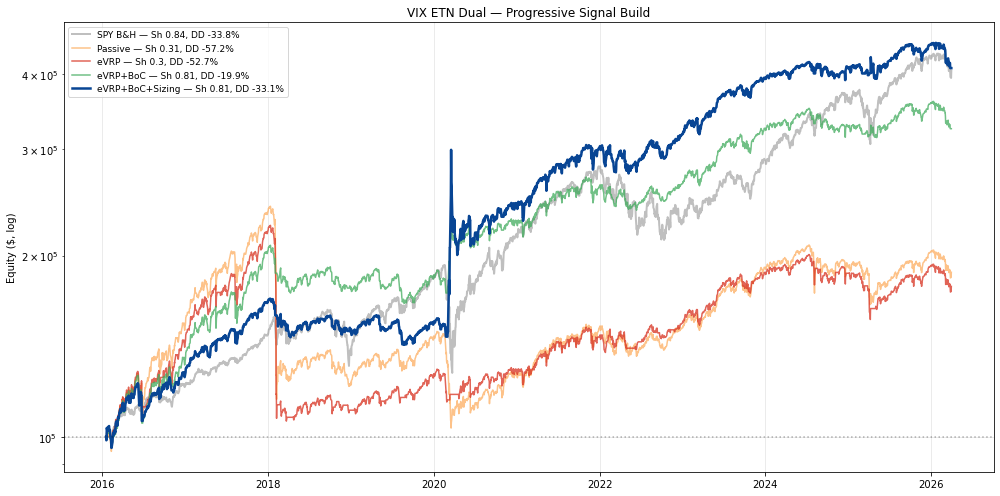

In [17]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(spy_eq.index.to_numpy(), spy_eq.values,
        color="gray", alpha=0.5, linewidth=2,
        label=f"SPY B&H — Sh {s_spy['sharpe']}, DD {s_spy['max_dd']}%")
colors = {"Passive": "#fdae61", "eVRP": "#d7301f",
          "eVRP+BoC": "#41ab5d", "eVRP+BoC+Sizing": "#084594"}
for name in strategy_order:
    eq = results[name]["equity_series"]
    s = results[name]["stats"]
    lw = 2.5 if name == CANONICAL_STRATEGY else 1.5
    alpha = 1.0 if name == CANONICAL_STRATEGY else 0.75
    ax.plot(eq.index.to_numpy(), eq.values, color=colors[name],
            linewidth=lw, alpha=alpha,
            label=f"{name} — Sh {s['sharpe']}, DD {s['max_dd']}%")
ax.axhline(STARTING_CAPITAL, color="black", linestyle=":", alpha=0.3)
ax.set_yscale("log")
ax.set_title(f"{STRATEGY_NAME} — Progressive Signal Build")
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_ylabel("Equity ($, log)")
plt.tight_layout(); plt.show()

## 11. Position Breakdown for Canonical Strategy

In [18]:
daily = canon["backtest"]["daily"]
pct_short = (daily["instrument"] == "vixshort").mean() * 100
pct_long  = (daily["instrument"] == "vixlong").mean()  * 100
pct_cash  = (daily["instrument"] == "cash").mean()     * 100
avg_weight = daily.loc[daily["instrument"] != "cash", "weight"].mean() * 100

print(f"{CANONICAL_STRATEGY} position breakdown:")
print(f"  % days in VIXSHORT:  {pct_short:.1f}%")
print(f"  % days in VIXLONG:   {pct_long:.1f}%")
print(f"  % days in CASH:      {pct_cash:.1f}%")
print(f"  Avg exposure (when in market): {avg_weight:.1f}%")

# Trade summary
trades = canon["backtest"]["trades"]
print(f"\nTrades: {len(trades)}")
if len(trades) > 0:
    print(f"  By instrument: {dict(trades['instrument'].value_counts())}")
    print(f"  Avg hold days: {(trades['exit_time'] - trades['entry_time']).dt.days.mean():.1f}")
    print(f"  Win rate: {(trades['pct_return_gross'] > 0).mean()*100:.1f}%")
    print(f"  Avg gross return: {trades['pct_return_gross'].mean()*100:.2f}%")

eVRP+BoC+Sizing position breakdown:
  % days in VIXSHORT:  92.4%
  % days in VIXLONG:   3.0%
  % days in CASH:      4.6%
  Avg exposure (when in market): 16.9%

Trades: 158
  By instrument: {'vixshort': 116, 'vixlong': 42}
  Avg hold days: 5.3
  Win rate: 57.0%
  Avg gross return: 2.72%


## 12. Save

In [19]:
import os, json

os.makedirs("results", exist_ok=True)

# Save canonical strategy trades in 9-col format
std_cols = ["entry_time", "exit_time", "direction", "instrument",
            "entry_price", "exit_price", "pct_return_gross", "exit_reason", "stop_price"]
canon_trades = canon["backtest"]["trades"]
canon_trades[std_cols].to_csv(f"results/{SAVE_NAME}_trades.csv", index=False)
print(f"Saved {len(canon_trades)} trades → results/{SAVE_NAME}_trades.csv")

# Save extended trades with entry_weight (used by Implementation)
ext_cols = std_cols + ["entry_weight"]
canon_trades[ext_cols].to_csv(f"results/{SAVE_NAME}_trades_extended.csv", index=False)

# Save daily equity for all 4 variants
for name in strategy_order:
    safe = name.replace("+", "_").replace(" ", "_").lower()
    eq = results[name]["equity_series"]
    eq.to_csv(f"results/{SAVE_NAME}_daily_equity_{safe}.csv")
spy_eq.to_csv(f"results/{SAVE_NAME}_daily_equity_spybench.csv")

summary = {
    "strategy": STRATEGY_NAME,
    "paper": "Zarattini, Mele & Aziz (2025) SFI Research Paper N°25-91",
    "instruments": SYMBOLS,
    "portfolio": "long_term",
    "period": f"{df['date'].iloc[0].date()} → {df['date'].iloc[-1].date()}",
    "params": {
        "realized_vol_window": REALIZED_VOL_WINDOW,
        "rebalance_threshold": REBALANCE_THRESHOLD,
        "annual_fee_short":    ANNUAL_FEE_SHORT,
        "annual_fee_long":     ANNUAL_FEE_LONG,
    },
    "canonical_strategy": CANONICAL_STRATEGY,
    "variants": {
        name: {"stats": results[name]["stats"], "n_trades": results[name]["n_trades"]}
        for name in strategy_order
    },
    "spy_benchmark": s_spy,
    "significance_canonical": {
        "sharpe":       report["bootstrap"]["observed_sharpe"],
        "verdict":      report["verdict"],
        "tests_passed": report["tests_passed"],
    },
}
with open(f"results/{SAVE_NAME}_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(f"Saved summary → results/{SAVE_NAME}_summary.json")
print(f"\nNext: run vix_etn_dual_Implementation.ipynb")

Saved 158 trades → results/vix_etn_dual_trades.csv
Saved summary → results/vix_etn_dual_summary.json

Next: run vix_etn_dual_Implementation.ipynb
